In [1]:
import numpy as np
import pandas as pd
import ast

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [2]:
df = pd.read_csv("./data/dessert_ing2inst.csv")

In [3]:
print(df)

           id                                 title  description  \
0      377129           Cream Cheese Fruit Dressing          NaN   
1      384652  Soft and Chewy Snickerdoodle Cookies          NaN   
2      251730           Spanish Honey-Almond Nougat          NaN   
3      187079                     Chewy Apple Drops          NaN   
4      261739                    Apple Rice Pudding          NaN   
...       ...                                   ...          ...   
60418  303619                   Pineapple Dream Pie          NaN   
60419   47167                 Diabetic Pumpkin Roll          NaN   
60420   54959                Chocolate Pudding Cake          NaN   
60421  189521                Orange Dessert Squares          NaN   
60422   92641                 Cantaloupe Brochettes          NaN   

                                             ingredients  \
0      ["250 cream cheese", "2 salt", "1 icing sugar"...   
1      ["1/2 salted butter", "1/2 shortening", "3 egg...   
2  

## Checking the length of dataset

In [4]:
len(df)

60423

In [5]:
df["ingredients"] = df["ingredients"].apply(ast.literal_eval)

In [6]:
print(df["ingredients"].iloc[0])

['250 cream cheese', '2 salt', '1 icing sugar', '1 sweet sherry', '1/2']


## Clearing data

In [7]:
dessert_keywords = ["cake", "cookie", "brownie", "pie", "muffin", "cupcake", "dessert"]

df = df[df["title"].str.lower().str.contains("|".join(dessert_keywords))]

In [8]:
len(df)

32020

In [9]:
import re

def clean_ingredient(ingredient):
    ingredient = ingredient.lower()
    
    # remove numbers and fractions
    ingredient = re.sub(r'\d+\/\d+|\d+', '', ingredient)
    
    # remove units
    units = ["cup", "cups", "tbsp", "tsp", "oz", "g", "kg"]
    for unit in units:
        ingredient = ingredient.replace(unit, "")
    
    # remove extra spaces
    ingredient = ingredient.strip()
    
    return ingredient

In [10]:
df["clean_ingredients"] = df["ingredients"].apply(
    lambda x: [clean_ingredient(i) for i in x]
)

In [11]:
print(df["clean_ingredients"].iloc[0])

['salted butter', 'shortenin', 'es', 'flour', 'suar', 'cream of tartar', 'bakin soda', 'salt', 'white suar', 'cinnamon']


## First analysis: Most common ingredients

In [12]:
from collections import Counter

all_ingredients = sum(df["clean_ingredients"], [])
Counter(all_ingredients).most_common(20)

[('', 39714),
 ('suar', 18280),
 ('butter', 17372),
 ('es', 17307),
 ('salt', 16299),
 ('bakin soda', 10824),
 ('bakin powder', 10673),
 ('flour', 10141),
 ('vanilla', 9677),
 ('all-purpose flour', 8476),
 ('vanilla extract', 8369),
 ('milk', 6851),
 ('water', 5642),
 ('brown suar', 5462),
 ('e', 5166),
 ('unsalted butter', 4896),
 ('powdered suar', 4697),
 ('cinnamon', 4571),
 ('ranulated suar', 4223),
 ('mararine', 3747)]

In [13]:
df["ingredient_count"] = df["clean_ingredients"].apply(len)

Text(0, 0.5, 'Frequency')

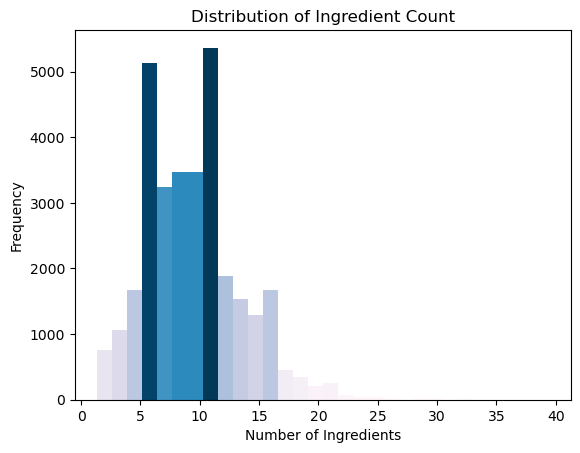

In [14]:
import matplotlib.pyplot as plt

data = df["ingredient_count"]

# create histogram manually
counts, bins = np.histogram(data, bins=30)

# normalize for color mapping
norm = counts / counts.max()

# choose colormap (purple → blue)
cmap = plt.cm.PuBu

# plot each bar with gradient color
for i in range(len(counts)):
    plt.bar(
        bins[i],
        counts[i],
        width=bins[i+1] - bins[i],
        color=cmap(norm[i])
    )

plt.title("Distribution of Ingredient Count")
plt.xlabel("Number of Ingredients")
plt.ylabel("Frequency")

## Second Analysis: Chocolate

In [15]:
df["has_chocolate"] = df["clean_ingredients"].apply(
    lambda x: any("chocolate" in i for i in x)
)

In [16]:
df.groupby("has_chocolate")["ingredient_count"].mean()

has_chocolate
False    10.085232
True     10.337787
Name: ingredient_count, dtype: float64

<Figure size 800x600 with 0 Axes>

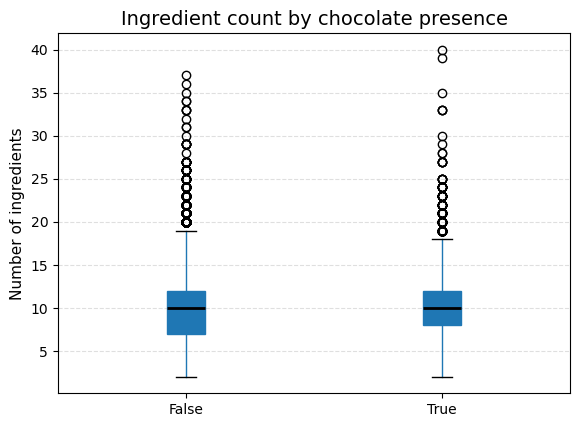

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# create boxplot
box = df.boxplot(
    column="ingredient_count",
    by="has_chocolate",
    patch_artist=True,
    grid=False
)

plt.suptitle("")

colors = ["#4f9dd9", "#6a5acd"]

for patch, color in zip(box.artists, colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

# style median line
for median in box.lines[4::6]:
    median.set_color("black")
    median.set_linewidth(2)

plt.title("Ingredient count by chocolate presence", fontsize=14)
plt.xlabel("")
plt.ylabel("Number of ingredients", fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

## Third Analysis: Comparison

In [18]:
def get_type(title):
    title = title.lower()
    if "cake" in title:
        return "cake"
    elif "cookie" in title:
        return "cookie"
    elif "brownie" in title:
        return "brownie"
    else:
        return "other"

df["type"] = df["title"].apply(get_type)

In [19]:
df_filtered = df[df["type"].isin(["cake", "cookie", "brownie"])]

<Figure size 800x600 with 0 Axes>

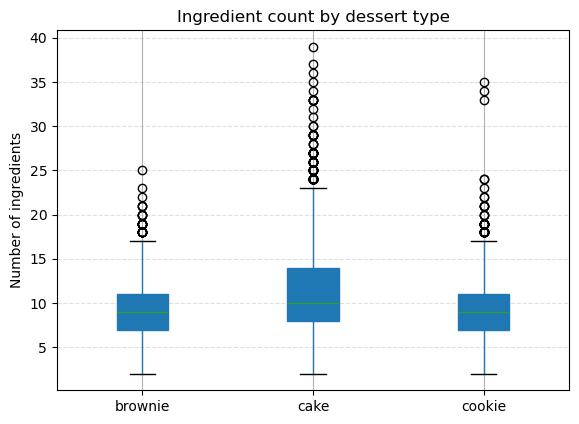

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

df_filtered.boxplot(
    column="ingredient_count",
    by="type",
    patch_artist=True
)

plt.suptitle("")
plt.title("Ingredient count by dessert type")
plt.xlabel("")
plt.ylabel("Number of ingredients")

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

In [21]:
df_filtered.groupby("type")["ingredient_count"].mean()

type
brownie     9.325676
cake       10.946745
cookie      9.110282
Name: ingredient_count, dtype: float64

## Fourth Analysis: What makes a dessert beginner-friendly?

In [22]:
df["ingredient_count"]

1        10
6        12
7        17
8         7
10        7
         ..
60415    13
60417    13
60418     6
60420    11
60421    15
Name: ingredient_count, Length: 32020, dtype: int64

In [23]:
df["step_count"] = df["steps"].apply(len)

In [24]:
df["total_minutes"]

1         75.0
6         60.0
7         60.0
8         65.0
10        75.0
         ...  
60415     60.0
60417     68.0
60418    135.0
60420     55.0
60421     45.0
Name: total_minutes, Length: 32020, dtype: float64

In [25]:
df_clean = df.dropna(subset=["ingredient_count", "step_count", "total_minutes"])

In [26]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_clean[["ingredient_scaled", "steps_scaled", "time_scaled"]] = scaler.fit_transform(
    df_clean[["ingredient_count", "step_count", "total_minutes"]]
)

In [27]:
df_clean["difficulty_score"] = (
    df_clean["ingredient_scaled"] +
    df_clean["steps_scaled"] +
    df_clean["time_scaled"]
)

In [28]:
easiest = df_clean.sort_values("difficulty_score").head(10)

In [29]:
easiest[["title", "ingredient_count", "step_count", "total_minutes", "difficulty_score"]]

,title,ingredient_count,step_count,total_minutes,difficulty_score
36951,Galaxy Piñata Cake,2,33,122.0,0.001129
40399,Lemon Sauce to Soak and Top Cake,2,59,5.0,0.002100
22820,No Bake Twinkie Pie,2,74,40.0,0.003610
29996,Pecan Pie Pudding,2,80,5.0,0.003760
5273,Instant Chocolate Yogurt Microwave Cake,2,91,2.0,0.004601
9603,Tiny Turkey Dinner Cupcakes,2,87,60.0,0.004822
17720,Luxury Dessert a La Clementines,2,99,5.0,0.005261
17929,Kerry's Apple Pie,2,101,65.0,0.005974
25469,"""motts"" Super Simple Carrot Cake (Tastes Like ...",2,114,35.0,0.006724
992,Connie's Very Fancy Grape Dessert,2,119,5.0,0.006841


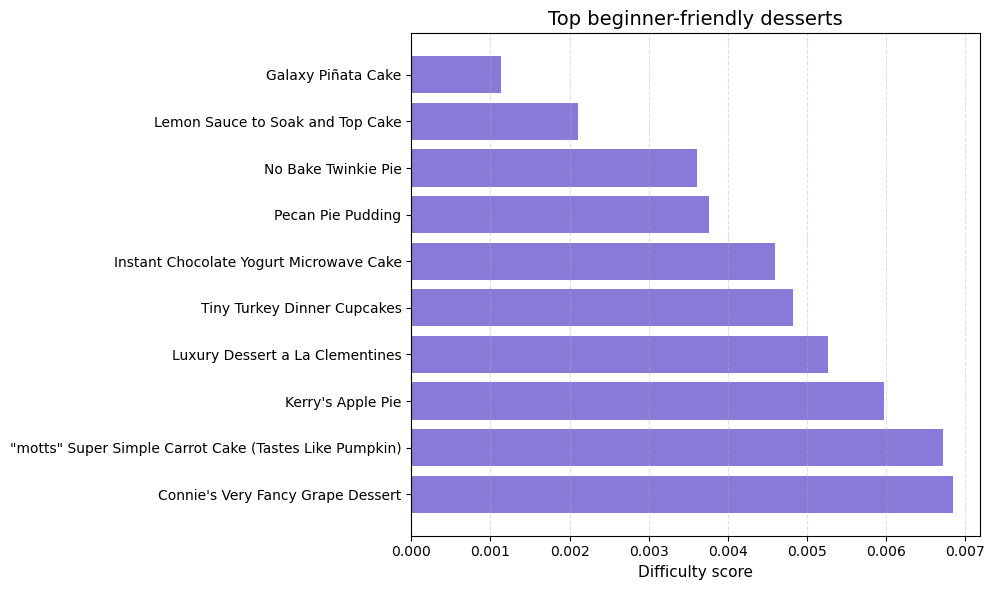

In [31]:
import matplotlib.pyplot as plt

easiest_sorted = easiest.sort_values("difficulty_score", ascending=True)

plt.figure(figsize=(10,6))

bars = plt.barh(
    easiest_sorted["title"],
    easiest_sorted["difficulty_score"],
    color="#6a5acd",   # soft purple
    alpha=0.8
)

plt.gca().invert_yaxis()

plt.title("Top beginner-friendly desserts", fontsize=14)
plt.xlabel("Difficulty score", fontsize=11)

plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.ylabel("")

plt.tight_layout()

plt.show()